In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
%matplotlib inline

In [3]:
data = pd.read_csv('master.csv')
data

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


In [4]:
data

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


Text(0.5, 1.0, 'Boxplot of population')

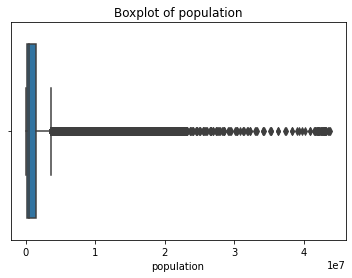

In [9]:
import seaborn as sns
sns.boxplot(x=data['population'])
plt.title("Boxplot of population")

Text(0.5, 1.0, 'Boxplot of GDP per Capita')

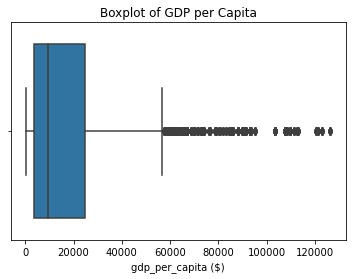

In [10]:
import seaborn as sns
sns.boxplot(x=data['gdp_per_capita ($)'])
plt.title("Boxplot of GDP per Capita")

Text(0.5, 1.0, 'Boxplot of suicidde per 100K population')

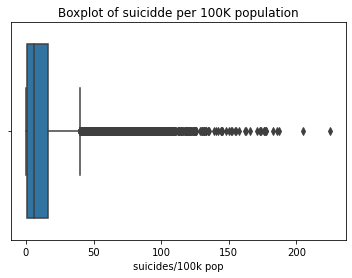

In [11]:
import seaborn as sns
sns.boxplot(x=data['suicides/100k pop'])
plt.title("Boxplot of suicidde per 100K population")

Text(0.5, 1.0, 'Number of suicides ')

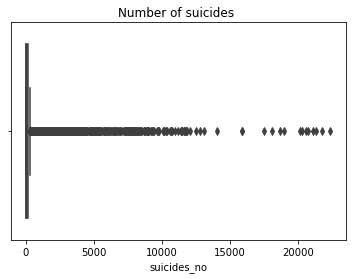

In [12]:
import seaborn as sns
sns.boxplot(x=data['suicides_no'])
plt.title("Number of suicides ")

In [57]:
data = data.drop(columns=["HDI for year", "suicides/100k pop"])
data = data.rename(columns={"gdp_for_year ($)": "gdp_for_year", "gdp_per_capita ($)": "gdp_per_capita", "country-year": "country_year"})

In [49]:
minimum_years = data.groupby("country").size().reset_index(name="years")
minimum_years["years"] = minimum_years["years"] / 12
data = data[~data["country"].isin(minimum_years[minimum_years["years"] <= 2]["country"])]

In [50]:
data["age"] = data["age"].str.replace(" years", "")
data["sex"] = data["sex"].map({"male": "Male", "female": "Female"})

In [42]:
# Get continent data
data["continent"] = data["country"].apply(lambda x: countryinfo(x).continent())

NameError: name 'countryinfo' is not defined

In [28]:
data_nominal = ['country', 'sex']
data[data_nominal] = data[data_nominal].astype('category')

In [29]:
data['age'] = pd.Categorical(data['age'], categories=["5-14", "15-24", "25-34", "35-54", "55-74", "75+"], ordered=True)

In [30]:
data['generation'] = pd.Categorical(data['generation'], 
                                   categories=["G.I. Generation",                                               "Silent",                                              "Boomers",                                               "Generation X",                                               "Millenials",                                               "Generation Z"], 
                                   ordered=True)

In [31]:
age_plot_data = data.groupby('age')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/2277259196.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_plot_data = data.groupby('age')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


<AxesSubplot:xlabel='age', ylabel='suicide_per_100k'>

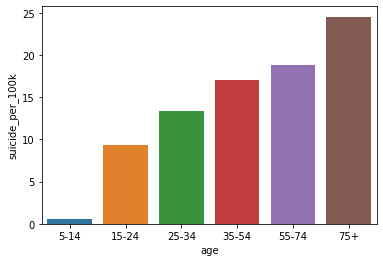

In [32]:
sns.barplot(x='age', y='suicide_per_100k', data=age_plot_data)

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/1512365155.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_time_plot_data = data.groupby(['year', 'age'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


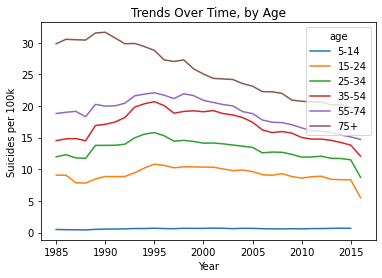

In [33]:
# Group the data by year and age and calculate the number of suicides per 100,000 people
age_time_plot_data = data.groupby(['year', 'age'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

# Create the line chart
sns.lineplot(x='year', y='suicide_per_100k', hue='age', data=age_time_plot_data)

# Set the title and axis labels
plt.title("Trends Over Time, by Age")
plt.xlabel("Year")
plt.ylabel("Suicides per 100k")

# Show the plot
plt.show()

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/1669840166.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sex_plot_data = data.groupby('sex')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


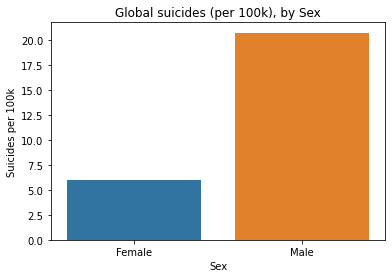

In [34]:
# Group the data by sex and calculate the number of suicides per 100,000 people
sex_plot_data = data.groupby('sex')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

# Create the bar chart
sns.barplot(x='sex', y='suicide_per_100k', data=sex_plot_data)

# Set the title and axis labels
plt.title("Global suicides (per 100k), by Sex")
plt.xlabel("Sex")
plt.ylabel("Suicides per 100k")

# Show the plot
plt.show()

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/1841135570.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sex_time_plot_data = data.groupby(['year', 'sex'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


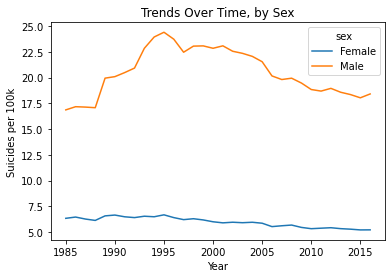

In [35]:
# Group the data by year and sex and calculate the number of suicides per 100,000 people
sex_time_plot_data = data.groupby(['year', 'sex'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

# Create the line chart
sns.lineplot(x='year', y='suicide_per_100k', hue='sex', data=sex_time_plot_data)

# Set the title and axis labels
plt.title("Trends Over Time, by Sex")
plt.xlabel("Year")
plt.ylabel("Suicides per 100k")

# Show the plot
plt.show()

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt



/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/1607089095.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  data = data.groupby(['year', 'sex'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


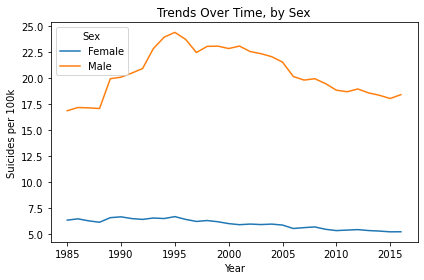

In [37]:
# Group the data by year and sex and calculate the number of suicides per 100,000 people
data = data.groupby(['year', 'sex'])['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

# Create the line chart
sns.lineplot(x='year', y='suicide_per_100k', hue='sex', data=data)

# Set the title and axis labels
plt.title("Trends Over Time, by Sex")
plt.xlabel("Year")
plt.ylabel("Suicides per 100k")

# Use the facet_wrap function to create separate plots for each category in the 'sex' column
plt.legend(title='Sex', loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/3980272876.py:5: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  male_data = data[data['sex'] == 'male'].groupby('year')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')
/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/3980272876.py:6: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  female_data = data[data['sex'] == 'female'].groupby('year')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')


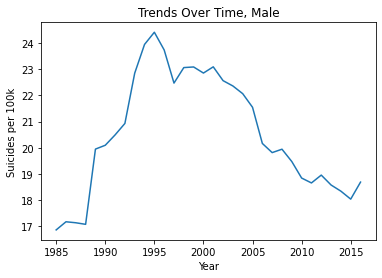

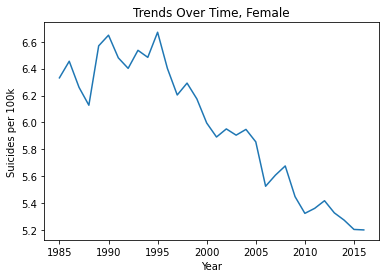

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group the data by sex and calculate the number of suicides per 100,000 people
male_data = data[data['sex'] == 'male'].groupby('year')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')
female_data = data[data['sex'] == 'female'].groupby('year')['suicides_no', 'population'].apply(lambda x: (x['suicides_no'].sum() / x['population'].sum()) * 100000).reset_index(name='suicide_per_100k')

# Create the line chart for male data
sns.lineplot(x='year', y='suicide_per_100k', data=male_data)

# Set the title and axis labels
plt.title("Trends Over Time, Male")
plt.xlabel("Year")
plt.ylabel("Suicides per 100k")

# Show the plot
plt.show()

# Create the line chart for female data
sns.lineplot(x='year', y='suicide_per_100k', data=female_data)

# Set the title and axis labels
plt.title("Trends Over Time, Female")
plt.xlabel("Year")
plt.ylabel("Suicides per 100k")

# Show the plot
plt.show()

In [44]:
country_year = data.groupby(['country', 'year'])['suicides_no', 'population', 'gdp_per_capita'].apply(lambda x: {'suicides': x['suicides_no'].sum(), 'population': x['population'].sum(), 'suicide_per_100k': (x['suicides_no'].sum() / x['population'].sum()) * 100000, 'gdp_per_capita': x['gdp_per_capita ($)'].mean()}).reset_index()

/var/folders/02/tj784j7j6fj3pjy7w95mhh100000gn/T/ipykernel_28177/3325122235.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  country_year = data.groupby(['country', 'year'])['suicides_no', 'population', 'gdp_per_capita'].apply(lambda x: {'suicides': x['suicides_no'].sum(), 'population': x['population'].sum(), 'suicide_per_100k': (x['suicides_no'].sum() / x['population'].sum()) * 100000, 'gdp_per_capita': x['gdp_per_capita ($)'].mean()}).reset_index()


KeyError: "Columns not found: 'gdp_per_capita'"

In [ ]:
country_year = data.groupby(['country', 'year']).agg(
    suicides=('suicides_no', 'sum'),
    population=('population', 'sum'),
    suicide_per_100k=(lambda x: (x['suicides'].sum() / x['population'].sum()) * 100000),
    gdp_per_capita=('gdp_per_capita', 'mean')
)

country_year_trends = (
    country_year.reset_index()
    .assign(
        data=lambda x: x.groupby('country')[['suicide_per_100k', 'year']].apply(
            lambda y: pd.DataFrame({'suicide_per_100k': y['suicide_per_100k'], 'year': y['year']})
        ).reset_index(drop=True).to_dict('records')
    )
    .assign(model=lambda x: x['data'].apply(
        lambda y: LinearRegression().fit(y[['year']], y[['suicide_per_100k']])
    ))
    .assign(tidied=lambda x: x['model'].apply(
        lambda y: pd.DataFrame({
            'term': ['year'],
            'estimate': [y.coef_[0]],
            'std.error': [np.sqrt(y.resid.var())],
            'statistic': [y.coef_[0] / np.sqrt(y.resid.var())],
            'p.value': [2 * (1 - t.cdf(np.abs(y.coef_[0] / np.sqrt(y.resid.var())), y.resid.shape[0] - 1))]
        })
    ))
    .explode('tidied')
    .reset_index(drop=True)
)

country_year_sig_trends = (
    country_year_trends[country_year_trends['tidied']['term'] == 'year']
    .assign(p_adjusted=lambda x: multip.multipletests(x['tidied']['p.value'], method='holm')[1])
    .query('p_adjusted < 0.05')
    .sort_values(by='tidied', ascending=True)
)

country_year_sig_trends['country'] = pd.Categorical(
    country_year_sig_trends['country'],
    categories=country_year_sig_trends['country'],
    ordered=True
)

In [ ]:
# group data by country and year, and summarize data
country_year = data.groupby(['country', 'year'])[['suicides_no', 'population', 'gdp_per_capita']].sum()


In [ ]:
# calculate suicide rate per 100k and gdp per capita mean
country_year['suicide_per_100k'] = (country_year['suicides_no'] / country_year['population']) * 100000
country_year['gdp_per_capita'] = data.groupby(['country', 'year'])['gdp_per_capita'].mean()

In [ ]:
# nest data by country
country_year_trends = country_year.reset_index().groupby('country').apply(lambda x: x[['year', 'suicide_per_100k']]).reset_index()
country_year_trends.rename(columns={'level_1': 'year', 0: 'suicide_per_100k'}, inplace=True)

In [ ]:
country_year_trends['model'] = country_year_trends.apply(lambda x: pd.ols(y=x['suicide_per_100k'], x=x['year'], intercept=True), axis=1)

In [ ]:
data

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(x="gdp_per_capita", y= "suicide_per_100k", data=data,
           scatter_kws={"s": 80}, height=8, aspect=1.5)
plt.title("Correlation between GDP (per capita) and Suicides per 100k")
plt.xlabel("GDP (per capita)")
plt.ylabel("Suicides per 100k")
plt.xscale("log")
plt.xticks(ticks=[0, 10000, 20000, 30000, 40000, 50000, 60000, 70000],
           labels=["$0", "$10000", "$20000", "$30000", "$40000", "$50000", "$60000", "$70000"])
plt.show()

KeyError: "None of [Index(['gdp_per_capita', 'suicide_per_100k'], dtype='object')] are in the [columns]"